In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib widget

In [2]:

def select_abundance_folder( minus:str):
    if minus=='Reaclib':
        folder = "Example_NSM_dyn_ejecta_rosswog_500dias"
    elif minus=='Reaclib with beta_exp': 
        folder = "Example_NSM_dyn_ejecta_rosswog_reaclib_beta_exp_out"
    elif minus=='Reaclib with alpha_exp': 
        folder = "Example_NSM_dyn_ejecta_rosswog_reaclib_alpha_exp_out"
    elif minus=='Reaclib with beta_exp and alpha_exp':
        folder = "Example_NSM_dyn_ejecta_rosswog_500dias_sin_theoretical_beta_alpha_out"
        
    return folder+'\snaps'

def read_abundance_file_A(file_path:str,folder:str):
    A=[0]
    abundances=[0]
    with open(os.path.join(folder, file_path), "r") as f:
    # skip 3 header lines
        for _ in range(3):
            next(f)

        for line in f:
            values = list(map(float, line.split()))
            A_=values[0]+values[1]
            if A_>A[-1]:
                A.append(A_)
                abundances.append(values[3])#X
            else:
                i=np.searchsorted(A, A_)
                abundances[i]+=values[3]
    return A, abundances


def times_abundance(folder:str):
    files=os.listdir(folder)
    time=[]
    for file in files:
        time.append(float(np.loadtxt(os.path.join(folder, file), skiprows=1,max_rows=1, usecols=0)))
    return time

def abundances_at_some_time(folder:str, time:float):
    files=os.listdir(folder)
    times=times_abundance(folder)
    i=np.searchsorted(times, time)
    return read_abundance_file_A(files[i],folder)

def general( minus:str, time:float):
    folder=select_abundance_folder(minus)
    return read_abundance_file_A(os.listdir(folder)[np.searchsorted(times_abundance(folder), time)], folder)



    

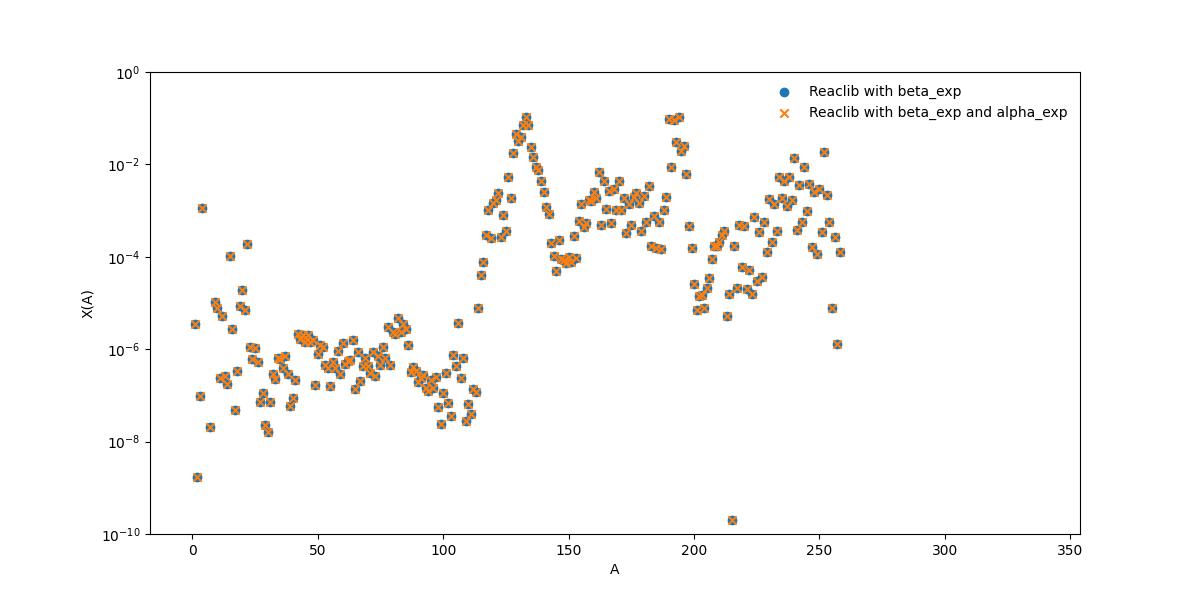

In [5]:
#A,abundances=general('Reaclib',8.64e5)
A1,abundances1=general('Reaclib with beta_exp',8.64e3)
#A2,abundances2=general('Reaclib with alpha_exp',8.64e5)
A3,abundances3=general('Reaclib with beta_exp and alpha_exp',8.64e3)
plt.figure(figsize=(12,6))
#plt.scatter(A, abundances, label='Reaclib')
plt.scatter(A1, abundances1, label='Reaclib with beta_exp')
#plt.scatter(A2, abundances2, label='Reaclib with alpha_exp')
plt.scatter(A3, abundances3, label='Reaclib with beta_exp and alpha_exp',marker='x')
plt.xlabel('A')
plt.ylabel('X(A)')
plt.yscale('log')
plt.ylim(1e-10,1)
plt.legend(frameon=False)

In [ ]:
'''Animation simulations'''

max_neutrons = 233
max_protons = 111
folder=select_abundance_folder(False, False, 'alpha and beta')
files = os.listdir(folder)

fig, ax = plt.subplots( figsize=(12,8))
log_heatmap_matrix = np.zeros((max_protons+ 1,max_neutrons + 1))-30
cax = ax.imshow(log_heatmap_matrix, origin='lower', cmap='plasma', aspect='auto',vmin=-30,vmax=0,extent=[-0.5, max_neutrons+0.5,0-0.5, max_protons+0.5])

def update(frame):
    
    with open(os.path.join(folder, files[frame*250]), "r") as f:
        # skip 3 header lines
        for _ in range(3):
            next(f)

        for line in f:
            values = list(map(float, line.split()))
            log_heatmap_matrix[int(values[1]), int(values[0])] = np.log10(values[3]+1e-30)#X
    cax.set_data(log_heatmap_matrix)
    return [cax]
    


Ani= animation.FuncAnimation(fig, update, frames=20, interval=200)
Ani.save("movie.gif")
